In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [10]:
df.fillna(df["TotalCharges"].mean())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [14]:
addon_services = [
    'MultipleLines', 
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport', 
    'StreamingTV', 
    'StreamingMovies'
]

services_df = pd.DataFrame()

for col in addon_services:
    services_df[col] = (df[col] == 'Yes').astype(int)

services_df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)

services_df['InternetService'] = (df['InternetService'] != 'No').astype(int)

df['TotalServices'] = services_df.sum(axis=1)


print(df[['customerID', 'tenure', 'MonthlyCharges', 'TotalServices', 'Churn']].head())
print('\n')
print(df['TotalServices'].value_counts().sort_index())

   customerID  tenure  MonthlyCharges  TotalServices Churn
0  7590-VHVEG       1           29.85              2    No
1  5575-GNVDE      34           56.95              4    No
2  3668-QPYBK       2           53.85              4   Yes
3  7795-CFOCW      45           42.30              4    No
4  9237-HQITU       2           70.70              2   Yes


TotalServices
1    1260
2     857
3     846
4     965
5     921
6     906
7     674
8     395
9     208
Name: count, dtype: int64


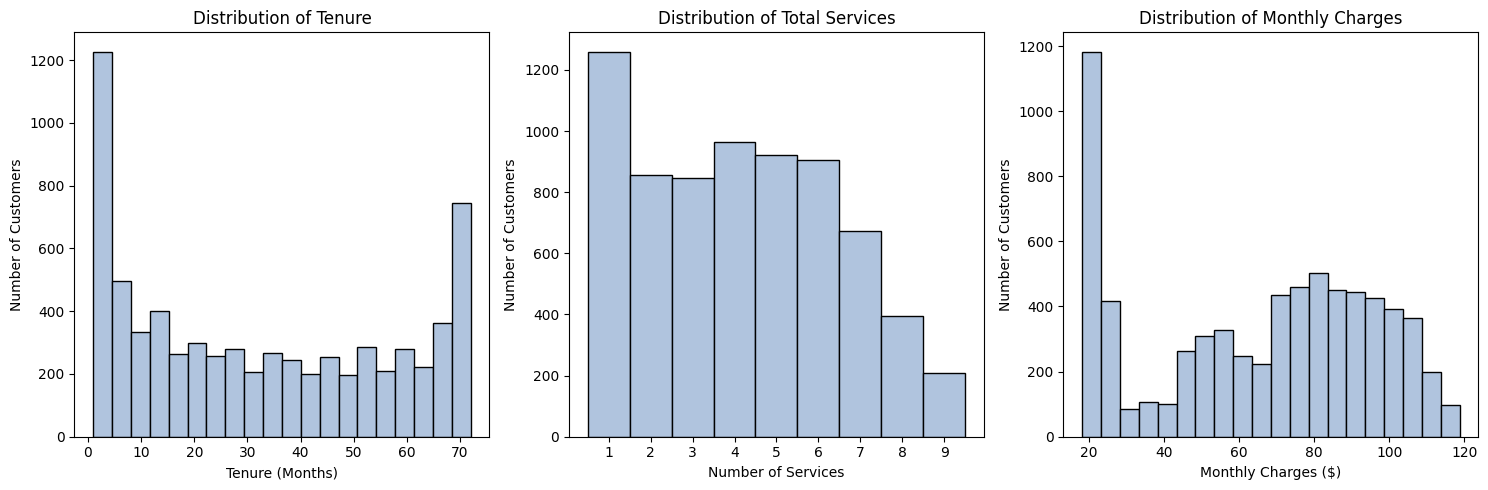

In [15]:

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5)) 

ax1.hist(df['tenure'], bins=20, color='lightsteelblue', edgecolor='black')
ax1.set_title('Distribution of Tenure')      
ax1.set_xlabel('Tenure (Months)')           
ax1.set_ylabel('Number of Customers')       

min_services = int(df['TotalServices'].min())
max_services = int(df['TotalServices'].max())

bins_services = range(min_services, max_services + 2) 

ax2.hist(df['TotalServices'], bins=bins_services, color='lightsteelblue', edgecolor='black', align='left')
ax2.set_title('Distribution of Total Services') 
ax2.set_xlabel('Number of Services')         
ax2.set_ylabel('Number of Customers')        
ax2.set_xticks(range(min_services, max_services + 1)) 

ax3.hist(df['MonthlyCharges'], bins=20, color='lightsteelblue', edgecolor='black')
ax3.set_title('Distribution of Monthly Charges') 
ax3.set_xlabel('Monthly Charges ($)')          
ax3.set_ylabel('Number of Customers')          

plt.tight_layout()
plt.show()

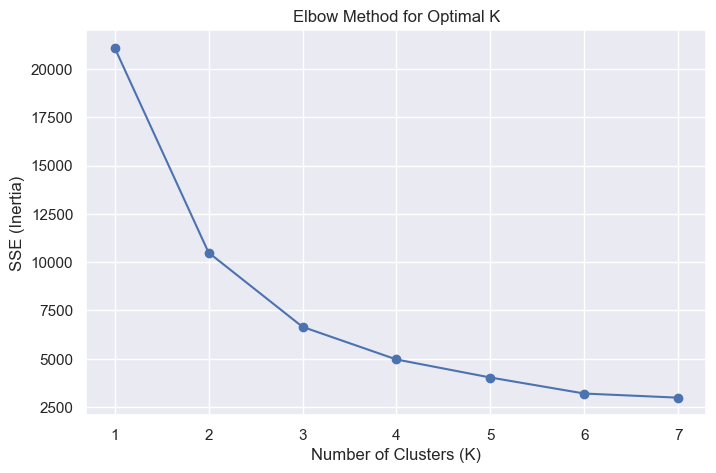

In [16]:
features_to_cluster = ['tenure', 'TotalServices', 'MonthlyCharges']
df_cluster_data = df[features_to_cluster]

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster_data)

SSE = []

k_range = range(1, 8, 1)

for i in k_range:

    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    
    kmeans.fit(X)
    
    SSE.append(kmeans.inertia_)

sns.set() 
plt.figure(figsize=(8, 5)) 
plt.plot(k_range, SSE, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range) 
plt.grid(True) 
plt.show()

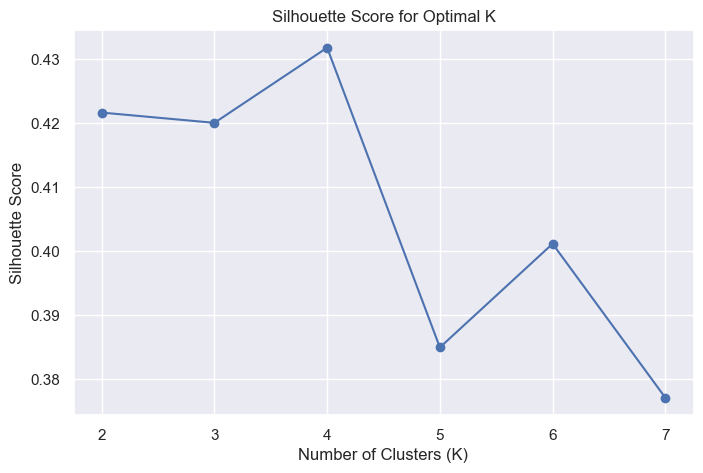

In [17]:
silhouette_scores = []

k_range = range(2, 8, 1)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    
    labels = kmeans.labels_
    
    score = silhouette_score(X, labels)
    
    silhouette_scores.append(score)

sns.set()
plt.figure(figsize=(8, 5))

plt.plot(k_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(k_range) 
plt.grid(True)
plt.show()

   tenure  TotalServices  MonthlyCharges  cluster
0       1              2           29.85        3
1      34              4           56.95        2
2       2              4           53.85        2
3      45              4           42.30        1
4       2              2           70.70        2
5       8              6           99.65        2
6      22              5           89.10        2
7      10              2           29.75        3
8      28              7          104.80        0
9      62              4           56.15        1


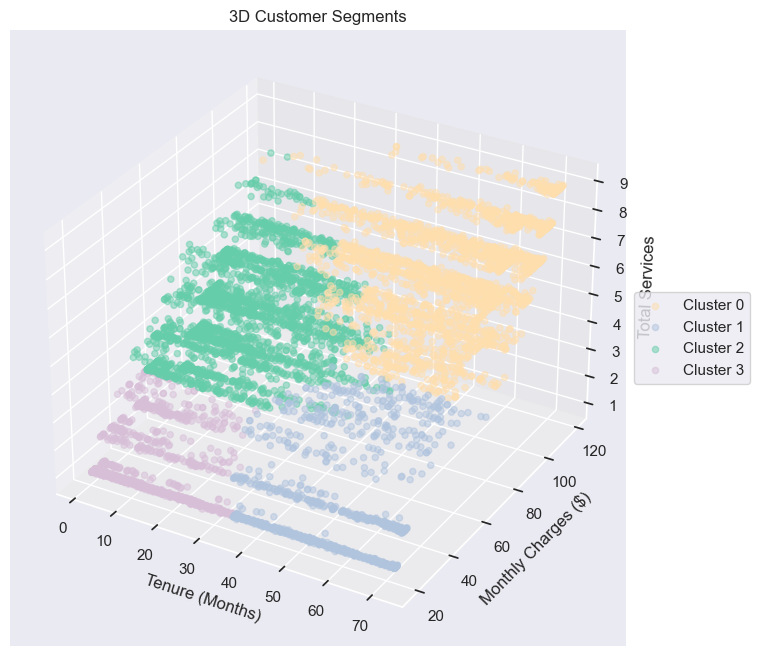

In [18]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

pred = kmeans.fit_predict(X)

df['cluster'] = pred

print(df[['tenure', 'TotalServices', 'MonthlyCharges', 'cluster']].head(10))

T = [] 
S = [] 
M = [] 

mycolors = ['navajowhite', 'lightsteelblue', 'mediumaquamarine', 'thistle'] 

for i in range(4):
    T.append(df.loc[df['cluster'] == i, 'tenure'].values.tolist())
    S.append(df.loc[df['cluster'] == i, 'TotalServices'].values.tolist())
    M.append(df.loc[df['cluster'] == i, 'MonthlyCharges'].values.tolist())

fig = plt.figure(figsize=(12, 8)) 
ax = fig.add_subplot(111, projection='3d') 

for i in range(4):
    ax.scatter(T[i], M[i], S[i], c=mycolors[i], marker='o', alpha=0.5, label=f'Cluster {i}')


ax.set_xlabel('Tenure (Months)')            
ax.set_ylabel('Monthly Charges ($)')      
ax.set_zlabel('Total Services')            
ax.set_title('3D Customer Segments')       
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
plt.show()

Cluster 0 = Premium Customers 
Cluster 1 = Loyal & Economic
Cluster 2 = Standard Customers
Cluster 3 = New & Economic

In [19]:
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print(df[['Churn', 'Churn_Numeric']].head())

  Churn  Churn_Numeric
0    No              0
1    No              0
2   Yes              1
3    No              0
4   Yes              1


Drop rate per cluster :
cluster
0    0.161639
1    0.041667
2    0.464032
3    0.224073
Name: Churn_Numeric, dtype: float64


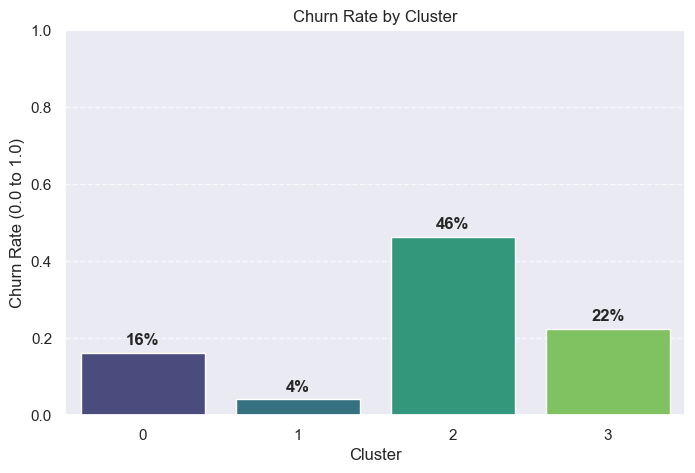

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


churn_rate = df.groupby('cluster')['Churn_Numeric'].mean()

print("Drop rate per cluster :")
print(churn_rate)

plt.figure(figsize=(8, 5))


sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')

plt.title('Churn Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (0.0 to 1.0)')
plt.ylim(0, 1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(churn_rate.values):
    plt.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

plt.show()

# --- Phase 2: Churn Prediction (XGBoost) ---

In [21]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop(columns=['customerID', 'Churn', 'Churn_Numeric'])

y = df['Churn_Numeric']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data dimensions: {X_train.shape}")
print(f"Test data dimensions: {X_test.shape}")
print("\nThe first 5 rows of prepared data (X_train):")
display(X_train.head()) 

Training data dimensions: (5625, 32)
Test data dimensions: (1407, 32)

The first 5 rows of prepared data (X_train):


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,TotalServices,cluster,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6030,0,43,49.05,2076.20,4,1,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
3410,0,3,53.40,188.70,3,2,True,False,False,True,...,False,True,False,False,False,False,False,True,False,False
5483,0,55,77.75,4458.15,4,0,False,True,False,True,...,False,False,False,False,False,False,True,False,True,False
5524,0,45,54.65,2553.70,4,1,True,True,True,True,...,False,False,False,False,False,True,False,False,False,False
6337,0,55,100.90,5448.60,6,0,False,True,True,True,...,False,True,False,True,True,False,False,False,False,True


In [22]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Accuracy Score (دقت کلی):
76.26%

Classification Report (گزارش کامل):
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1033
           1       0.56      0.47      0.51       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.76      1407



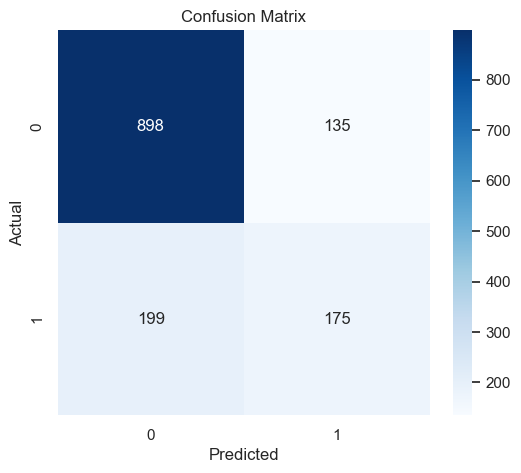

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score (دقت کلی):")
print(f"{accuracy_score(y_test, y_pred):.2%}")

print("\nClassification Report (گزارش کامل):")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [24]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from scipy.stats import uniform, randint
import numpy as np

X = df.drop(columns=['customerID', 'Churn', 'Churn_Numeric'])
X = pd.get_dummies(X, drop_first=True)
y = df['Churn_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Balancing training data with SMOTEENN...")
sm = SMOTEENN(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"Basic training data: {X_train.shape}")
print(f"Balanced Training Data: {X_train_res.shape}")
print("-" * 30)

models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [10, 20]}),
    
    ('XG Boost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 6], 'n_estimators': [100, 200]}),
    
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000),
        {'C': [0.1, 1, 10]}),
    
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'max_depth': [10, 20], 'min_samples_split': [5, 10]}),
        
    ('Naive Bayes', GaussianNB(), {})
]

model_scores = []
best_model = None
best_accuracy = 0.0

for name, model, param_grid in models:
    print(f"Training the model: {name} ...")
    
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_res)
    X_test_scaled = scaler.transform(X_test)

    final_model = model
    if param_grid:
        search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, 
                                    n_iter=5, cv=3, random_state=42, n_jobs=-1, verbose=0)
        search.fit(X_train_scaled, y_train_res)
        final_model = search.best_estimator_
    else:
        final_model.fit(X_train_scaled, y_train_res)

    y_pred = final_model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    model_scores.append({'Model': name, 'Accuracy': accuracy})
    
    print(f"--> (Accuracy): {accuracy:.2%}")
    print("-" * 30)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = final_model

# --- نمایش نتایج نهایی ---
print("\n" + "="*30)
print("Final comparison table:")
scores_df = pd.DataFrame(model_scores).sort_values(by='Accuracy', ascending=False)
print(scores_df)
print("="*30)

Balancing training data with SMOTEENN...
Basic training data: (5625, 32)
Balanced Training Data: (4679, 32)
------------------------------
Training the model: Random Forest ...
--> (Accuracy): 73.56%
------------------------------
Training the model: XG Boost ...
--> (Accuracy): 73.49%
------------------------------
Training the model: Logistic Regression ...
--> (Accuracy): 74.63%
------------------------------
Training the model: Decision Tree ...
--> (Accuracy): 72.64%
------------------------------
Training the model: Naive Bayes ...
--> (Accuracy): 63.82%
------------------------------

Final comparison table:
                 Model  Accuracy
2  Logistic Regression  0.746269
0        Random Forest  0.735608
1             XG Boost  0.734897
3        Decision Tree  0.726368
4          Naive Bayes  0.638237


Finding the best settings for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 Best Accuracy achieved: 73.92%

Best Parameters found:
{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.71      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



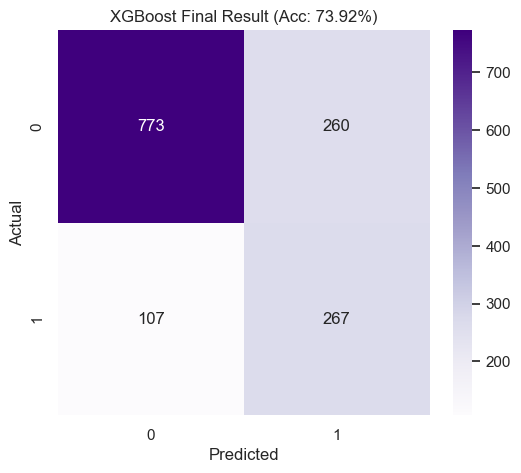

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


X = df.drop(columns=['customerID', 'Churn', 'Churn_Numeric', 'TotalCharges'])

X = pd.get_dummies(X, drop_first=True)
y = df['Churn_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=ratio  
)

param_grid = {
    'n_estimators': [100, 200, 300],        
    'learning_rate': [0.01, 0.05, 0.1],     
    'max_depth': [3, 4, 5, 6],              
    'min_child_weight': [1, 3, 5],          
    'gamma': [0, 0.1, 0.2, 0.3],            
    'subsample': [0.7, 0.8, 0.9],           
    'colsample_bytree': [0.7, 0.8, 0.9]     
}

print("Finding the best settings for XGBoost...")
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(f" Best Accuracy achieved: {acc:.2%}")
print("="*40)

print("\nBest Parameters found:")
print(random_search.best_params_)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'XGBoost Final Result (Acc: {acc:.2%})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

 The best threshold found: 0.79
 Highest possible accuracy with this model: 78.61%

Final Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       0.81      0.93      0.86      1033
           1       0.66      0.40      0.50       374

    accuracy                           0.79      1407
   macro avg       0.74      0.66      0.68      1407
weighted avg       0.77      0.79      0.77      1407



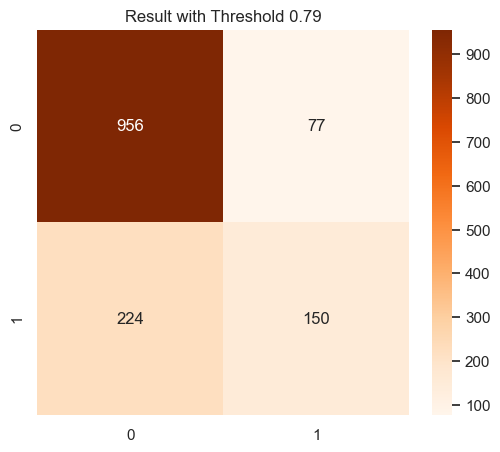

In [27]:
from sklearn.metrics import accuracy_score
import numpy as np

y_pred_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
scores = []

for t in thresholds:
    y_pred_temp = (y_pred_proba > t).astype(int)
    acc = accuracy_score(y_test, y_pred_temp)
    scores.append(acc)

best_threshold_index = np.argmax(scores)
best_threshold = thresholds[best_threshold_index]
best_acc = scores[best_threshold_index]

print(f" The best threshold found: {best_threshold:.2f}")
print(f" Highest possible accuracy with this model: {best_acc:.2%}")

y_pred_final = (y_pred_proba > best_threshold).astype(int)

print("\nFinal Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_final))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Oranges')
plt.title(f'Result with Threshold {best_threshold:.2f}')
plt.show()

 The model competition begins...

 Training Logistic Regression...
 Training Random Forest...
 Training SVM...
 Training KNN...
 Training Decision Tree...
 Training XGBoost...

 Final standings
                 Model  Accuracy  F1-Score    Recall  Precision
1        Random Forest  0.776830  0.518405  0.451872   0.607914
3                  KNN  0.748401  0.512397  0.497326   0.528409
0  Logistic Regression  0.734186  0.612033  0.788770   0.500000
5              XGBoost  0.731343  0.560465  0.644385   0.495885
2                  SVM  0.729922  0.601677  0.767380   0.494828
4        Decision Tree  0.712154  0.456376  0.454545   0.458221


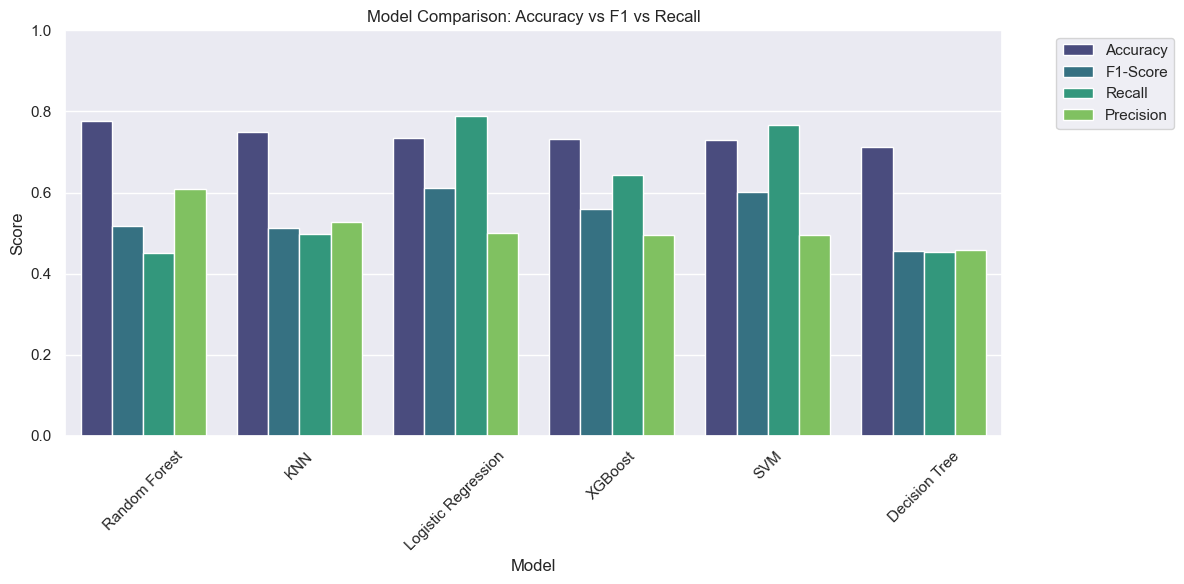

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


models = [
    ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    
    ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)),
    
    ('SVM', SVC(class_weight='balanced', random_state=42)),
    
    ('KNN', KNeighborsClassifier()), 

    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    
    ('XGBoost', XGBClassifier(scale_pos_weight=3, use_label_encoder=False, eval_metric='logloss', random_state=42))
]

results = []

print(" The model competition begins...\n")

for name, model in models:
    print(f" Training {name}...")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1,      
        'Recall': recall,    
        'Precision': prec
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print(" Final standings")
print("="*50)
print(results_df)

plt.figure(figsize=(12, 6))

melted_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(x='Model', y='Score', hue='Metric', data=melted_df, palette='viridis')
plt.title('Model Comparison: Accuracy vs F1 vs Recall')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 Using the optimized model XGBoost

 5 main factors that cause hair loss:
                             Feature  Importance
26                 Contract_Two year    0.238593
15  OnlineBackup_No internet service    0.180322
11       InternetService_Fiber optic    0.083919
25                 Contract_One year    0.080042
4                            cluster    0.038077


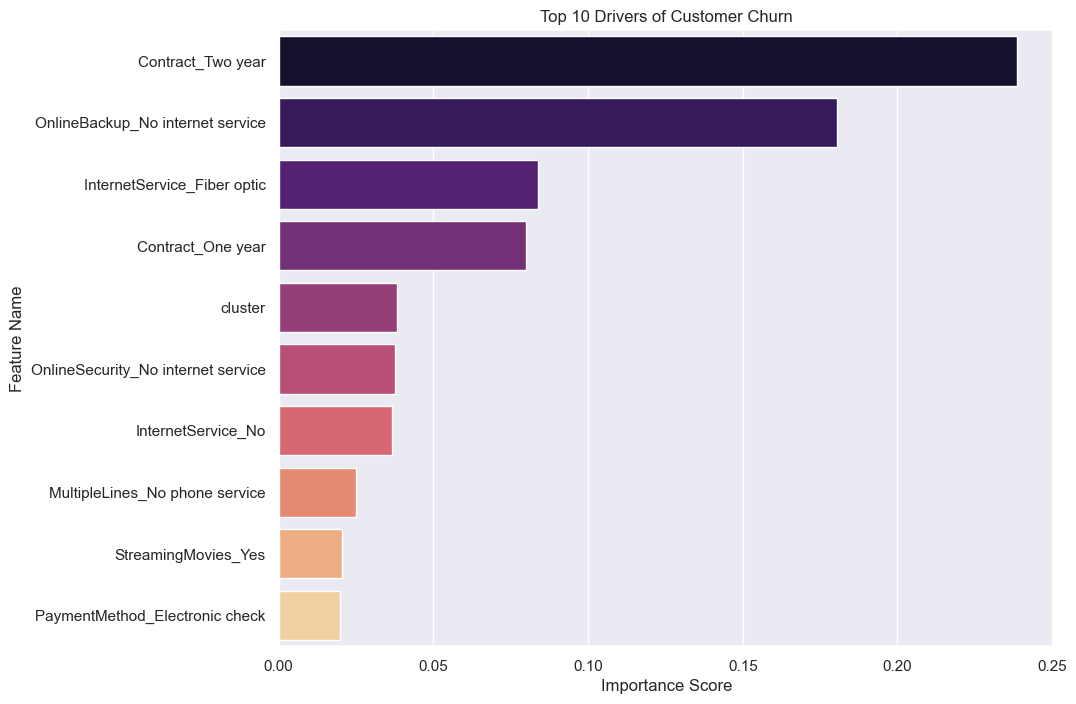

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    final_model = best_xgb
    print(" Using the optimized model XGBoost")
except NameError:
    from sklearn.ensemble import RandomForestClassifier
    final_model = RandomForestClassifier(class_weight='balanced', random_state=42)
    final_model.fit(X_train_scaled, y_train)
    print(" Using the model Random Forest")

importances = final_model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n 5 main factors that cause hair loss:")
print(feature_imp_df.head(5))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='magma')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [30]:
import joblib

joblib.dump(best_xgb, 'final_churn_model_xgb.pkl')

print(" Model saved successfully ")

 Model saved successfully 
